<a href="https://colab.research.google.com/github/Shreyapowar9961/Deep_Learning_sem6/blob/main/DL_LAB_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name - Shreya Nandkumar Powar

TY DS

Roll No - 65

PRN - 2324001231


In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shreyapowar9961","key":"be69d2dccc99027c49b6560e78431dd4"}'}

In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:30<00:00, 81.7MB/s]



In [5]:
!unzip -q chest-xray-pneumonia.zip

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

In [7]:
train_path = "/content/chest_xray/train"
test_path = "/content/chest_xray/test"
val_path = "/content/chest_xray/val"

In [8]:
IMG_SIZE = 64
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 94s 282ms/step - accuracy: 0.8219 - loss: 0.4041 - val_accuracy: 0.8125 - val_loss: 0.4453
Epoch 2/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 90s 277ms/step - accuracy: 0.9097 - loss: 0.2245 - val_accuracy: 0.8750 - val_loss: 0.4266
Epoch 3/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 144s 282ms/step - accuracy: 0.9126 - loss: 0.2141 - val_accuracy: 0.7500 - val_loss: 0.6235


In [13]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_data)
print("CNN Test Accuracy:", cnn_accuracy * 100)

39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - accuracy: 0.8157 - loss: 0.4978
CNN Test Accuracy: 81.57051205635071


In [14]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

/tmp/ipykernel_10078/863987081.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
base_model.trainable = False

In [17]:
tl_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [18]:
tl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
tl_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
tl_history = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 90s 258ms/step - accuracy: 0.8322 - loss: 0.3727 - val_accuracy: 0.6875 - val_loss: 0.4471
Epoch 2/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 80s 244ms/step - accuracy: 0.8909 - loss: 0.2694 - val_accuracy: 0.7500 - val_loss: 0.4182
Epoch 3/3
326/326 ━━━━━━━━━━━━━━━━━━━━ 77s 236ms/step - accuracy: 0.8986 - loss: 0.2474 - val_accuracy: 0.8125 - val_loss: 0.2950


In [21]:
tl_loss, tl_accuracy = tl_model.evaluate(test_data)
print("Transfer Learning Accuracy:", tl_accuracy * 100)

39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 214ms/step - accuracy: 0.8093 - loss: 0.5394
Transfer Learning Accuracy: 80.92948794364929


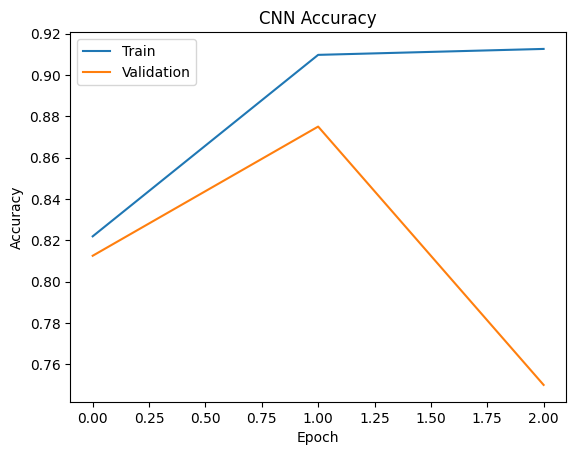

In [22]:
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

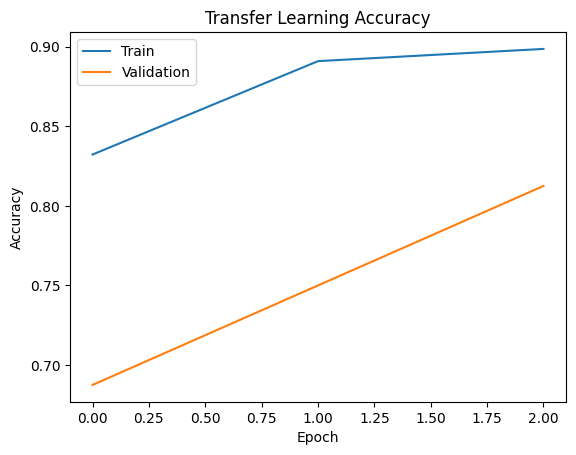

In [23]:
plt.plot(tl_history.history['accuracy'])
plt.plot(tl_history.history['val_accuracy'])
plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

In [24]:
cnn_model.save("cnn_pneumonia_model.h5")
tl_model.save("transfer_learning_pneumonia_model.h5")